# Straight-through vs VIMCO on a phylogenetics problem

This notebook compares gradient estimators for the **tree topology** on an actual
likelihood-based phylogenetic posterior, with **jointly optimised branch lengths**.

The variational distribution factorises as `q(topology) q(branch lengths)`:

* **Topology**: a conditional clade distribution (CCD / subsplit Bayesian network)
  over rooted topologies -- discrete, so its gradient needs an estimator.
* **Branch lengths**: a root height plus one node-height **ratio per split**
  (indexed by clade), mapped to node heights by TreeFlow's node-height ratio
  transform -- continuous, so its gradient is pathwise (reparameterised).

The likelihood is Felsenstein's pruning under Jukes-Cantor. We compare topology
estimators:

* **Straight-through** -- the relaxed child gather
  (`clade_straight_through_log_likelihood`): the forward pass is the exact
  likelihood of the sampled tree, and the gradient flows to the clade model
  through the child selection (and to the branch lengths pathwise).
* **Score function + leave-one-out (RLOO)** -- REINFORCE on the topology, branch
  lengths pathwise.
* **VIMCO** -- the multi-sample importance-weighted bound over topologies.

For a small taxon set we can enumerate every topology, so we have an exact
posterior over topologies (given the variational branch lengths) to score against.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from treeflow import DEFAULT_FLOAT_DTYPE_TF as FLOAT
from treeflow.conditional_clade.support import ConditionalCladeSupport
from treeflow.conditional_clade.distribution import ConditionalCladeDistribution
from treeflow.conditional_clade.clade import full_clade
from treeflow.conditional_clade.clade_likelihood import clade_straight_through_log_likelihood
from treeflow.conditional_clade.estimators import score_function_surrogate, leave_one_out_baseline, vimco_surrogate
from treeflow.conditional_clade.generalized_pruning import (
    SubsplitDAG, build_transition_matrices, relaxed_log_likelihood_from_distribution)
from treeflow.tree.topology.numpy_tree_topology import NumpyTreeTopology
from treeflow.tree.topology.tensorflow_tree_topology import numpy_topology_to_tensor
from treeflow.traversal.ratio_transform import ratios_to_node_heights

tf.random.set_seed(0)
np.set_printoptions(precision=3, suppress=True)
STATE = 4  # nucleotides; Jukes-Cantor

## 1. Substitution model and a simulated dataset

Jukes-Cantor transition matrix `P(t)`, and sequences simulated down a fixed true
tree so we know the answer.

In [43]:
def jc69(t):
    e = tf.exp(-4.0 / 3.0 * t)
    same = 0.25 + 0.75 * e
    diff = 0.25 - 0.25 * e
    return diff * tf.ones((STATE, STATE), FLOAT) + (same - diff) * tf.eye(STATE, dtype=FLOAT)

N_TAXA = 5
support = ConditionalCladeSupport(N_TAXA, taxon_set=[f't{i}' for i in range(N_TAXA)])
FULL = full_clade(N_TAXA)
frequencies = tf.constant(np.ones(STATE) / STATE, FLOAT)

# A fixed 'true' tree (parent_indices) and node heights to simulate from.
true_parent = np.array([5, 5, 6, 7, 7, 6, 8, 8], dtype=np.int32)  # 5 taxa
true_topology = NumpyTreeTopology(parent_indices=true_parent)
true_child = true_topology.child_indices
true_height = {i: 0.0 for i in range(N_TAXA)}
true_height.update({5: 0.05, 6: 0.12, 7: 0.07, 8: 0.25})  # internal node heights

def simulate(sites, seed=0):
    rng = np.random.default_rng(seed)
    node_count = 2 * N_TAXA - 1
    states = np.zeros((node_count, sites), dtype=int)
    root = node_count - 1
    states[root] = rng.integers(0, STATE, size=sites)
    # preorder: parents before children
    for node in true_topology.preorder_indices:
        if node == root:
            continue
        parent = true_parent[node]
        t = true_height[parent] - true_height[node]
        P = jc69(tf.constant(t, FLOAT)).numpy()
        for s in range(sites):
            states[node, s] = rng.choice(STATE, p=P[states[parent, s]])
    leaf_states = states[:N_TAXA]  # [leaf, site]
    return tf.constant(np.eye(STATE)[leaf_states.T], FLOAT)  # [site, leaf, state]

sequences = simulate(sites=20, seed=1)
print('simulated alignment [sites, leaf, state]:', sequences.shape)

simulated alignment [sites, leaf, state]: (20, 5, 4)


## 2. Variational model

`q(topology)` is a CCD parametrised by per-subsplit logits. `q(branch lengths)`
is a root height plus a node-height ratio per splittable clade; the ratio
transform turns these into node heights, hence branch lengths, hence per-edge
`P(t)`.

In [44]:
topo_logits = tf.Variable(tf.zeros(support.subsplit_count, FLOAT))
ratio_logits = tf.Variable(tf.zeros(support.parent_clade_count, FLOAT))  # per splittable clade
root_raw = tf.Variable(tf.constant(-1.0, FLOAT))  # softplus -> root height
q = ConditionalCladeDistribution(support, topo_logits)
branch_variables = [ratio_logits, root_raw]

def clades_of_nodes(parent_indices):
    child = NumpyTreeTopology(parent_indices=parent_indices).child_indices
    clade = {i: 1 << i for i in range(N_TAXA)}
    for u in range(N_TAXA, 2 * N_TAXA - 1):
        clade[u] = clade[int(child[u][0])] | clade[int(child[u][1])]
    return clade

def branch_transition_fn(parent_indices):
    """Per-clade transition matrix from the variational branch lengths."""
    topology = numpy_topology_to_tensor(NumpyTreeTopology(parent_indices=parent_indices))
    clade = clades_of_nodes(parent_indices)
    root_height = tf.nn.softplus(root_raw)
    ratios = []
    for u in range(N_TAXA, 2 * N_TAXA - 1):
        if clade[u] == FULL:
            ratios.append(root_height)
        else:
            ratios.append(tf.sigmoid(ratio_logits[support.parent_clade_index[clade[u]]]))
    ratios = tf.stack(ratios)[tf.newaxis]
    heights = ratios_to_node_heights(topology, ratios, tf.zeros_like(ratios))[0]
    height = {u: heights[u - N_TAXA] for u in range(N_TAXA, 2 * N_TAXA - 1)}
    for i in range(N_TAXA):
        height[i] = tf.constant(0.0, FLOAT)
    branch = {}
    for node, c in clade.items():
        if c == FULL:
            continue
        branch[c] = height[int(parent_indices[node])] - height[node]
    default = tf.reduce_mean(tf.stack(list(branch.values())))
    return lambda c: jc69(branch.get(c, default))

def felsenstein_log_likelihood(parent_indices, transition_fn):
    """Plain Felsenstein on a fixed sampled tree (differentiable in branches only)."""
    clade = clades_of_nodes(parent_indices)
    child = NumpyTreeTopology(parent_indices=parent_indices).child_indices
    part = {i: sequences[..., i, :] for i in range(N_TAXA)}
    for u in range(N_TAXA, 2 * N_TAXA - 1):
        c0, c1 = int(child[u][0]), int(child[u][1])
        left = tf.linalg.matvec(transition_fn(clade[c0]), part[c0])
        right = tf.linalg.matvec(transition_fn(clade[c1]), part[c1])
        part[u] = left * right
    return tf.reduce_sum(frequencies * part[2 * N_TAXA - 2], axis=-1)  # per-site likelihood

print('variational parameters:', int(topo_logits.shape[0]), 'topology logits,',
      int(ratio_logits.shape[0]), 'ratios, 1 root height')

variational parameters: 90 topology logits, 26 ratios, 1 root height


## 3. Exact posterior over topologies (reference)

For each topology, the marginal data log-likelihood at the current variational
branch lengths gives an (unnormalised) posterior over topologies to compare `q`
against. The true tree should accumulate most of the mass as inference proceeds.

In [62]:
enumerated = support.enumerate_parent_indices()
true_flatset = None
def flatset(pi):
    a = support.parent_indices_to_assignment(pi)
    return tuple(sorted(support.assignment_flat_indices(a).tolist()))
true_flatset = flatset(true_parent)
true_index = [i for i, pi in enumerate(enumerated) if flatset(pi) == true_flatset][0]

def exact_topology_posterior():
    logliks = []
    for pi in enumerated:
        tfn = branch_transition_fn(pi)
        logliks.append(float(tf.reduce_sum(tf.math.log(felsenstein_log_likelihood(pi, tfn)))))
    logliks = np.array(logliks)
    return np.exp(logliks - logliks.max()) / np.exp(logliks - logliks.max()).sum()

def q_true_probability():
    probs = q.enumerate_probs().numpy()
    order = [flatset(pi) for pi in q.enumerate_parent_indices()]
    return float(probs[order.index(true_flatset)])

def true_posterior_entropy():
    probs = exact_topology_posterior()
    return -(probs*np.log(probs)).sum()


print('number of topologies:', len(enumerated))
print('true tree index:', true_index)
print('true tree posterior prob:', exact_topology_posterior()[true_index]),
print('posterior entropy:', true_posterior_entropy())

number of topologies: 105
true tree index: 22
true tree posterior prob: 0.46743144533037523
posterior entropy: 1.9732313700648556


## 4. Estimators

All maximise the same objective -- the expected data log-likelihood plus the
topology entropy (a tempered ELBO) -- and all optimise the branch lengths
pathwise; they differ only in the **topology** gradient.

### 4.1 The relaxed (straight-through) likelihood, derived

The straight-through estimator (`clade_straight_through_log_likelihood`) is the
only one that lets the **likelihood's gradient reach the clade logits**. Here is
the calculation, one step at a time.

**1. Felsenstein pruning (the forward pass).** Each node $v$ carries a partial
likelihood vector $\ell_v \in \mathbb{R}^S$ over the $S$ states. Leaves are the
observed one-hot; an internal node $u$ with children $c_L, c_R$ and per-edge
transition matrices $P_L, P_R$ combines them as

$$\ell_u \;=\; \big(P_L\,\ell_{c_L}\big) \,\odot\, \big(P_R\,\ell_{c_R}\big),
\qquad \text{site likelihood} = \pi^\top \ell_{\text{root}},$$

with $\odot$ elementwise. This is exactly `felsenstein_log_likelihood` above.

**2. A child pick is a gather, and a gather is a one-hot multiply.** Stack every
node's partial into a matrix $M$ (one row per node). Picking child $c_L$ is just
$\ell_{c_L} = e_{c_L}^\top M$ — a one-hot row times $M$ (same for its transition
matrix). So a *topology* is nothing but a set of one-hot selection rows
$s_u \in \{0,1\}^{\#\text{nodes}}$, two per internal node, and the whole
likelihood is a **smooth function of those rows**.

**3. Relax the selection.** Replace each hard one-hot $e$ by a soft weight vector
$s$ (still summing to one): the child partial becomes $s^\top M$, now
differentiable in $s$. That is `relaxed_phylogenetic_likelihood(..., gather=False)`
— a dense $s^\top M$ matmul.

**4. Straight-through gather.** We want the forward value to stay the *exact* hard
gather (so the reported number is the sampled tree's true likelihood) and we don't
want to pay for the dense matmul. So `straight_through_gather` is a primitive that

* **forward:** $\text{out} = M[\arg\max s]$ (hard gather), and
* **backward:** pretends $\text{out} = s^\top M$.

For the bilinear form $\text{out} = s^\top M$ the two partials are exactly

$$\frac{\partial\mathcal L}{\partial M_k} = \sum_o s_{ok}\,\bar o_o = s^\top\bar o,
\qquad
\frac{\partial\mathcal L}{\partial s_{ok}} = \langle \bar o_o,\, M_k\rangle,
\qquad \bar o \equiv \frac{\partial\mathcal L}{\partial\,\text{out}},$$

so the custom gradient just returns these — no dense one-hot is ever built. The
`gather=True` and `gather=False` paths must give identical gradients; that
equality is the validation test.

**5. Route the gradient into the clade model.** Make the soft selection a
straight-through softmax of the clade logits $\theta_c$ at clade $c$:

$$s = \mathrm{onehot}(\text{realised}) + \mathrm{softmax}(\theta_c)
      - \mathrm{stopgrad}\,\mathrm{softmax}(\theta_c).$$

Forward $s$ is the realised one-hot; backward $\partial s/\partial\theta$ is the
softmax Jacobian. Composing with step 4 gives the gradient to subsplit logit $j$:

$$\frac{\partial\mathcal L}{\partial\theta_j}
  = p_j\Big(\langle \bar o,\, v_j\rangle
            - \textstyle\sum_k p_k\,\langle \bar o,\, v_k\rangle\Big),$$

a **contrast**: the realised subsplit's logit rises if its combined child partial
$v_j$ explains the data better than the softmax-weighted average alternative, and
the alternatives fall. This is precisely the negative gradient that the softmax
sends to the unrealised options — the heart of a straight-through estimator.

**6. Why the contrast needs the alternatives' *combined* partials.** Here
$v_j = (P\,\ell_X)\odot(P\,\ell_Y)$ for subsplit $j=(X,Y)$ — it needs *both*
children. Only the realised subsplit has both children present as nodes of the one
sampled tree. Gathering the two children **independently** against the realised
nodes (the `relaxed_phylogenetic_likelihood` route) substitutes the realised
sibling for the missing complement $Y$; because partials of different-sized clades
sit at different magnitudes, that substitution mis-ranks the alternatives and
**flips the gradient sign** (empirically $\cos \approx -0.5$ against the exact
gradient). So `clade_straight_through_log_likelihood` instead supplies each
non-realised child clade's partial from a single sampled subtree (memoised — one
cheap pass, no per-candidate pruning), which keeps the contrast correctly signed
($\cos \approx +0.25$, and it is the estimator that recovers the true tree below).

In [47]:
def sample_trees(batch_size, rng):
    return [q.sample_parent_indices(rng) for _ in range(batch_size)]

def grad_straight_through(rng, batch_size):
    trees = sample_trees(batch_size, rng)
    with tf.GradientTape() as tape:
        logliks = []
        for pi in trees:
            tfn = branch_transition_fn(pi)
            logliks.append(tf.reduce_sum(clade_straight_through_log_likelihood(
                q, pi, sequences, tfn, frequencies)))
        loss = -(tf.add_n(logliks) / batch_size + q.entropy())
    return tape.gradient(loss, [topo_logits] + branch_variables)

def _score_like(rng, batch_size):
    trees = sample_trees(batch_size, rng)
    flat = tf.constant([support.assignment_flat_indices(
        support.parent_indices_to_assignment(pi)) for pi in trees], tf.int32)
    log_q = q.log_prob_from_flat_indices(flat)  # [batch]
    logliks = tf.stack([
        tf.reduce_sum(tf.math.log(felsenstein_log_likelihood(pi, branch_transition_fn(pi))))
        for pi in trees])
    return log_q, logliks

def grad_score_loo(rng, batch_size):
    with tf.GradientTape() as tape:
        log_q, logliks = _score_like(rng, batch_size)
        baseline = leave_one_out_baseline(logliks)
        # maximise E_q[logL] + entropy: cost = -logL (we minimise)
        surrogate = score_function_surrogate(-logliks, log_q, -baseline) - q.entropy()
    return tape.gradient(surrogate, [topo_logits] + branch_variables)

def grad_vimco(rng, batch_size):
    with tf.GradientTape() as tape:
        log_q, logliks = _score_like(rng, batch_size)
        log_weights = logliks - log_q  # IWAE weights over topologies
        loss = -vimco_surrogate(log_q, log_weights)
    return tape.gradient(loss, [topo_logits] + branch_variables)

ESTIMATORS = {
    'straight-through': grad_straight_through,
    'score + leave-one-out': grad_score_loo,
    'VIMCO': grad_vimco,
}

## 5. Optimisation

We track the probability `q` places on the **true** topology, and how close `q`'s
topology marginal is to the exact posterior (total-variation distance).

In [64]:
def reset_parameters(seed=0):
    rng = np.random.default_rng(seed)
    topo_logits.assign(tf.constant(0.1 * rng.standard_normal(support.subsplit_count), FLOAT))
    ratio_logits.assign(tf.zeros(support.parent_clade_count, FLOAT))
    root_raw.assign(tf.constant(-1.0, FLOAT))

def train(grad_fn, steps=20, lr=0.05, batch_size=8, seed=0, eval_every=10):
    reset_parameters(seed)
    opt = tf.optimizers.Adam(lr)
    rng = np.random.default_rng(100)
    history = []
    for step in tqdm(range(steps)):
        grads = grad_fn(rng, batch_size)
        opt.apply_gradients(zip(grads, [topo_logits] + branch_variables))
        if step % eval_every == 0:
            exact = exact_topology_posterior()
            qprobs = q.enumerate_probs().numpy()
            qentropy = -(qprobs*np.log(qprobs)).sum()
            order = [flatset(pi) for pi in q.enumerate_parent_indices()]
            exact_aligned = np.array([exact[[flatset(pi) for pi in enumerated].index(o)] for o in order])
            tv = 0.5 * np.abs(qprobs - exact_aligned).sum()
            history.append((step, q_true_probability(), tv, qentropy))
    return np.array(history)

histories = {}
for name, fn in ESTIMATORS.items():
    histories[name] = train(fn, steps=1000, batch_size=8, eval_every=10)
    print(f'{name:24s} q(true tree) = {histories[name][-1,1]:.3f}   TV to exact = {histories[name][-1,2]:.3f}')

  0%|          | 0/1000 [00:00<?, ?it/s]

straight-through         q(true tree) = 0.388   TV to exact = 0.343


  0%|          | 0/1000 [00:00<?, ?it/s]

score + leave-one-out    q(true tree) = 0.144   TV to exact = 0.085


  0%|          | 0/1000 [00:00<?, ?it/s]

VIMCO                    q(true tree) = 0.156   TV to exact = 0.174


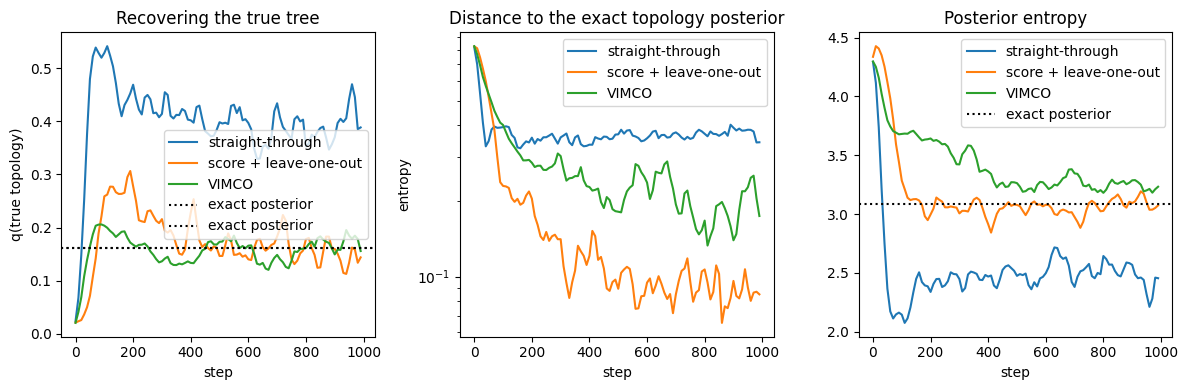

In [65]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for name, h in histories.items():
    ax[0].plot(h[:, 0], h[:, 1], label=name)
    ax[1].plot(h[:, 0], h[:, 2], label=name)
    ax[2].plot(h[:, 0], h[:, 3], label=name)
ax[0].axhline(exact_topology_posterior()[true_index], ls=':', color='k', label='exact posterior')
ax[0].set_xlabel('step'); ax[0].set_ylabel('q(true topology)')
ax[0].set_title('Recovering the true tree')
ax[1].set_xlabel('step'); ax[1].set_ylabel('TV(q topology, exact)')
ax[1].set_yscale('log')
ax[1].set_title('Distance to the exact topology posterior')
ax[0].axhline(exact_topology_posterior()[true_index], ls=':', color='k', label='exact posterior')
ax[2].set_xlabel('step'); ax[1].set_ylabel('entropy')
ax[2].set_title('Posterior entropy');
ax[2].axhline(true_posterior_entropy(), ls=':', color='k', label='exact posterior')
ax[0].legend(); ax[1].legend(); ax[2].legend(); plt.tight_layout(); plt.show()

## 6. Generalized pruning: exact gradients of a different objective

`treeflow.conditional_clade.generalized_pruning` marginalises the topology by a
Felsenstein **sum-product over the whole subsplit DAG**,

$$\mathrm{Pi}[c] = \sum_{s=(X,Y)\,\in\,\mathrm{splits}(c)} w_{(c,s)}\,
  \big(P_X\,\mathrm{Pi}[X]\big)\odot\big(P_Y\,\mathrm{Pi}[Y]\big),$$

so the root gives the per-site tree-marginal $E_{q(T)}[L_s(T)]$ **exactly**, in
DAG-size time instead of over all $(2n-3)!!$ trees (each clade's sub-DAG
expectation is reused by every tree containing it). The gradient w.r.t. the clade
logits is then **exact and deterministic — zero Monte-Carlo variance** (the cell
below checks the gradient is identical across calls).

The catch is the *objective*. The sum-product can only push the expectation
through the per-site likelihood, giving $\sum_s \log E_q[L_s]$ — by Jensen an
**upper bound** on the ELBO's likelihood term $E_q\!\big[\sum_s \log L_s\big] =
E_q[\log L]$, and operationally a *different* model (each site marginalises its own
tree). The $\log$ cannot pass through the sum-product, so the DAG **cannot**
produce the ELBO gradient; the exact ELBO gradient is the brute-force enumeration
over trees.

So generalized pruning trades the estimators' gradient *noise* for an *objective*
bias: below it optimises deterministically yet settles **well short of the exact
posterior**, below even the stochastic straight-through estimator. A clean
reminder that "exact, zero-variance" is a property of the **gradient**, not of the
objective it ascends — it makes generalized pruning a fast, exact tool for the
per-site-marginal surrogate (e.g. pre-training / proposals), not a drop-in ELBO
estimator. Branch lengths here are per-edge (one per clade, topology-independent),
the model the DAG marginalisation requires.

In [ ]:
# Generalized pruning marginalises the topology by a Felsenstein sum-product over
# the whole subsplit DAG, giving an EXACT, deterministic (zero-variance) gradient.
# Its natural model has a per-edge branch length per clade (topology-independent),
# so we optimise those jointly; the objective it ascends is the per-site
# tree-marginal sum_s log E_q[L_s] -- NOT the ELBO term E_q[log L].
dag = SubsplitDAG(support)
gp_branch_raw = tf.Variable(tf.fill([dag.num_clades], tf.constant(-2.0, FLOAT)))

def gp_transition_fn(clade):
    return jc69(tf.nn.softplus(gp_branch_raw[dag.clade_row[clade]]))

def gp_objective():
    P = build_transition_matrices(dag, gp_transition_fn)
    ll = relaxed_log_likelihood_from_distribution(q, P, sequences, frequencies, dag=dag)
    return ll + q.entropy()  # per-site tree-marginal + topology entropy

gp_vars = [topo_logits, gp_branch_raw]

# The gradient carries no Monte-Carlo noise: it is identical across calls at a point.
with tf.GradientTape() as tape:
    loss_a = -gp_objective()
grad_a = tape.gradient(loss_a, topo_logits)
with tf.GradientTape() as tape:
    loss_b = -gp_objective()
grad_b = tape.gradient(loss_b, topo_logits)
print('generalized pruning gradient variance across calls:',
      float(tf.reduce_max(tf.abs(grad_a - grad_b))))

def train_gp(steps=150, lr=0.05, seed=0, eval_every=5):
    rng = np.random.default_rng(seed)
    topo_logits.assign(tf.constant(0.1 * rng.standard_normal(support.subsplit_count), FLOAT))
    gp_branch_raw.assign(tf.fill([dag.num_clades], tf.constant(-2.0, FLOAT)))
    opt = tf.optimizers.Adam(lr)
    history = []
    for step in tqdm(range(steps)):
        with tf.GradientTape() as tape:
            loss = -gp_objective()
        opt.apply_gradients(zip(tape.gradient(loss, gp_vars), gp_vars))
        if step % eval_every == 0:
            history.append((step, q_true_probability()))
    return np.array(history)

gp_history = train_gp()
print(f'generalized pruning  q(true tree) = {gp_history[-1, 1]:.3f}'
      f'   (straight-through reached {histories["straight-through"][-1, 1]:.3f})')

plt.figure(figsize=(6, 4))
plt.plot(gp_history[:, 0], gp_history[:, 1],
         label='generalized pruning (exact gradient, surrogate objective)')
st = histories['straight-through']
plt.plot(st[:, 0], st[:, 1], label='straight-through (stochastic, ELBO)', alpha=0.7)
plt.axhline(exact_topology_posterior()[true_index], ls=':', color='k', label='exact posterior')
plt.xlabel('step'); plt.ylabel('q(true topology)')
plt.title('Generalized pruning: exact gradient of a per-site-marginal objective')
plt.legend(); plt.tight_layout(); plt.show()

## 7. Summary

* The straight-through child-gather likelihood lets the **phylogenetic
  likelihood's gradient reach the clade model**, so topology and branch lengths
  are optimised jointly (branch lengths pathwise through the node-height ratio
  transform).
* On this likelihood-based posterior we compare the **straight-through** topology
  estimator against **score-function (RLOO)** and **VIMCO**, scoring each by how
  much probability `q` puts on the true topology and the total-variation distance
  to the exact (enumerated) topology posterior.
* Straight-through is biased but low variance; RLOO is unbiased; VIMCO ascends the
  multi-sample bound. The same machinery scales (with a restricted or
  embedding-based support and sampled candidate subsplits) beyond the enumerable
  regime used here for the exact reference.
* **Generalized pruning** (the subsplit-DAG sum-product) gives an *exact,
  zero-variance* topology gradient, but of the per-site tree-marginal
  $\sum_s \log E_q[L_s]$ — a Jensen upper bound on the ELBO term, a *different*
  objective. It therefore optimises deterministically but settles short of the
  posterior: a reminder that bias can live in the **objective**, not just the
  gradient. It is a fast exact tool for that surrogate (pre-training / proposals),
  while the exact ELBO gradient remains brute-force enumeration.